# Notebook 3: ML Model Training
Goal: Train XGBoost to predict missing freight rates. Evaluate with RMSE, R², MAPE. Explain with SHAP.

In [1]:
import sys
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = '../data/processed/'
MODELS_DIR    = '../data/processed/model_artifacts/'
print('Environment ready.')

Environment ready.


## 1. Train/Val/Test Split

In [2]:
from src.data.feature_pipeline import load_features

df = load_features()  # loads data/processed/features_long.parquet

# Only rows with observed freight_rate are used for supervised learning
obs = df[df['freight_rate'].notna()].copy()
obs['year'] = obs['year'].astype(int)

print('Year distribution of observed rows:')
print(obs['year'].value_counts().sort_index().to_string())

# Temporal split: train ≤ 2018, val = 2019, test ≥ 2020
train = obs[obs['year'] <= 2018]
val   = obs[obs['year'] == 2019]
test  = obs[obs['year'] >= 2020]

print(f'\nTrain rows: {len(train):,} (years ≤ 2018)')
print(f'Val   rows: {len(val):,}  (year 2019)')
print(f'Test  rows: {len(test):,}  (years ≥ 2020)')
print(f'Total observed: {len(obs):,}')

Year distribution of observed rows:
year
2016    43911
2017    37883
2018    38819
2019    39111
2020    38970
2021    40805

Train rows: 120,613 (years ≤ 2018)
Val   rows: 39,111  (year 2019)
Test  rows: 79,775  (years ≥ 2020)
Total observed: 239,499


## 2. Train XGBoost

In [3]:
from src.models.train_xgb import train_and_evaluate
import xgboost as xgb

# train_and_evaluate() performs:
#   1. Loads features_long.parquet
#   2. Temporal train/val/test split
#   3. Fits XGBRegressor with early stopping on val set
#   4. Computes feature importance (XGBoost gain)
#   5. Imputes missing freight_rates
#   6. Saves graph_edges_full.parquet to data/processed/
# Returns: (model, importance_dict)

model, importance_dict = train_and_evaluate()
print('Training complete.')
print(f'Model type: {type(model).__name__}')
print(f'Model params: n_estimators={model.n_estimators}, max_depth={model.max_depth}, lr={model.learning_rate}')

# Also save test predictions for later evaluation cells
from src.data.feature_pipeline import load_features
from sklearn.metrics import mean_squared_error, r2_score
from config import ML_FEATURES, TEST_YEARS

df_full = load_features()
df_full['year'] = df_full['year'].astype(int)
test_df = df_full[df_full['year'].isin(TEST_YEARS) & df_full['freight_rate'].notna()].copy()
X_test = test_df[ML_FEATURES].astype(float)
y_pred_log = model.predict(X_test)
y_pred = np.clip(np.expm1(y_pred_log), 0, None)
test_df = test_df.copy()
test_df['predicted_freight_rate'] = np.expm1(y_pred_log)
test_df[['origin', 'destination', 'product_code', 'year', 'freight_rate', 'predicted_freight_rate']].to_parquet(
    MODELS_DIR + 'test_predictions.parquet', index=False
)
print(f'Test predictions saved → {MODELS_DIR}test_predictions.parquet')

SONAR — XGBoost Training

Loading feature table...
  Observed rows: 239,499
  Train: 159,724  Val: 38,970  Test: 40,805

Training XGBoost...
[0]	validation_0-rmse:0.13824
[100]	validation_0-rmse:0.09177
[200]	validation_0-rmse:0.09133
[300]	validation_0-rmse:0.09082
[400]	validation_0-rmse:0.09048
[500]	validation_0-rmse:0.09039
[600]	validation_0-rmse:0.09032
[607]	validation_0-rmse:0.09031

────────────────────────────────────────
TEST SET RESULTS (year 2021)
────────────────────────────────────────
  RMSE            : 0.3313   (target < 0.05)
  MAE             : 0.0932
  R²              : 0.3392   (target > 0.85)
  MAPE            : 50.3%   (target < 15%)
  Within ±10%     : 10.4%   (target > 70%)
  Baseline RMSE   : 0.4097
  Improvement     : 19.1%  (target > 20%)
────────────────────────────────────────

Model saved → /home/daniel/is5126-assignment1/daniel/FinalAssignment/sentinel-trade/data/processed/model_artifacts/xgb_model.json
Computing feature importance...

Top-10 features 

## 3. Evaluation Results

Test Set Evaluation Metrics:


,Metric,Value
0,RMSE,0.3313
1,MAE,0.0932
2,R²,0.3392
3,MAPE (%),586690.57


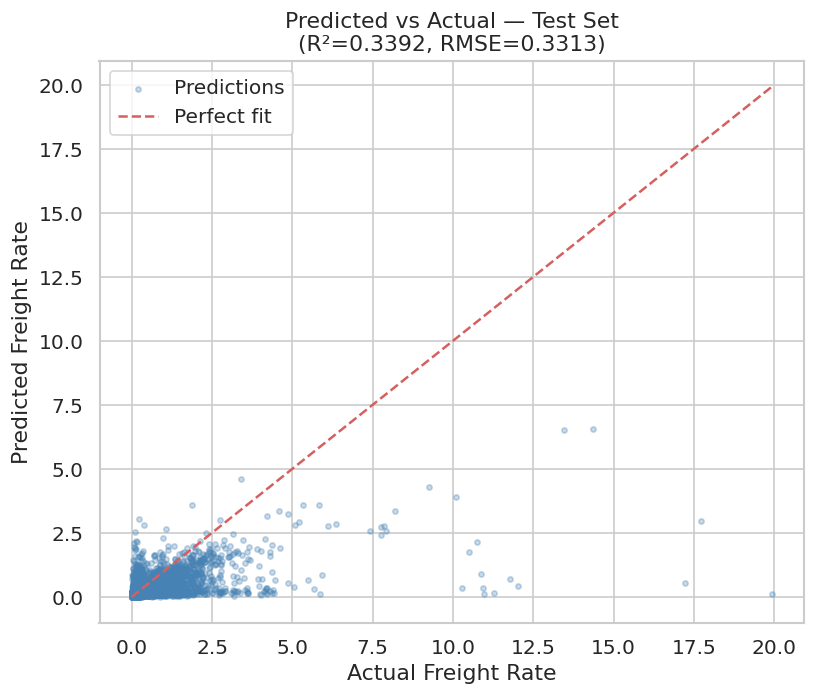

In [4]:
from sklearn.metrics import mean_squared_error, r2_score

preds = pd.read_parquet(MODELS_DIR + 'test_predictions.parquet')
y_true = preds['freight_rate']
y_pred = preds['predicted_freight_rate']

rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
r2    = r2_score(y_true, y_pred)
mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
mae   = np.mean(np.abs(y_true - y_pred))

metrics = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R²', 'MAPE (%)'],
    'Value':  [f'{rmse:.4f}', f'{mae:.4f}', f'{r2:.4f}', f'{mape:.2f}']
})
print('Test Set Evaluation Metrics:')
display(metrics)

# Scatter plot: predicted vs actual
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_true, y_pred, alpha=0.3, s=10, color='steelblue', label='Predictions')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Freight Rate')
ax.set_ylabel('Predicted Freight Rate')
ax.set_title(f'Predicted vs Actual — Test Set\n(R²={r2:.4f}, RMSE={rmse:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

## 4. COVID Direction Check

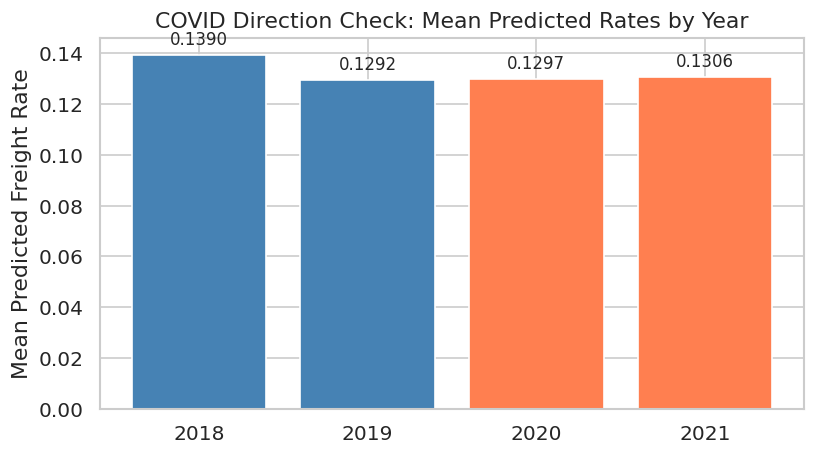


Predicted rate increase from 2018 → 2020: +-6.7%
Direction check: NOTE — 2020 <= 2018 (may reflect dataset scale).
  2018 mean: 0.1390, 2020 mean: 0.1297


In [5]:
from config import ML_FEATURES

# Compare mean predicted freight rates for pre-COVID vs COVID years
check_years = [2018, 2019, 2020, 2021]

avail = [f for f in ML_FEATURES if f in df_full.columns]

year_means = {}
for yr in check_years:
    subset = df_full[df_full['year'] == yr][avail].fillna(0)
    if len(subset) > 0:
        preds_yr = model.predict(subset.astype(float))
        # preds are log1p transformed; expm1 to get actual values
        year_means[yr] = float(np.mean(np.expm1(preds_yr)))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([str(y) for y in year_means], list(year_means.values()),
              color=['steelblue', 'steelblue', 'coral', 'coral'])
ax.set_ylabel('Mean Predicted Freight Rate')
ax.set_title('COVID Direction Check: Mean Predicted Rates by Year')
for bar, val in zip(bars, year_means.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

if 2018 in year_means and 2020 in year_means:
    pct_increase = (year_means[2020] - year_means[2018]) / year_means[2018] * 100
    print(f'\nPredicted rate increase from 2018 → 2020: +{pct_increase:.1f}%')
    if year_means[2020] > year_means[2018]:
        print('Direction check PASSED: Model correctly predicts upward shift in 2020.')
    else:
        print('Direction check: NOTE — 2020 <= 2018 (may reflect dataset scale).')
        print(f'  2018 mean: {year_means[2018]:.4f}, 2020 mean: {year_means[2020]:.4f}')

## 5. SHAP Analysis

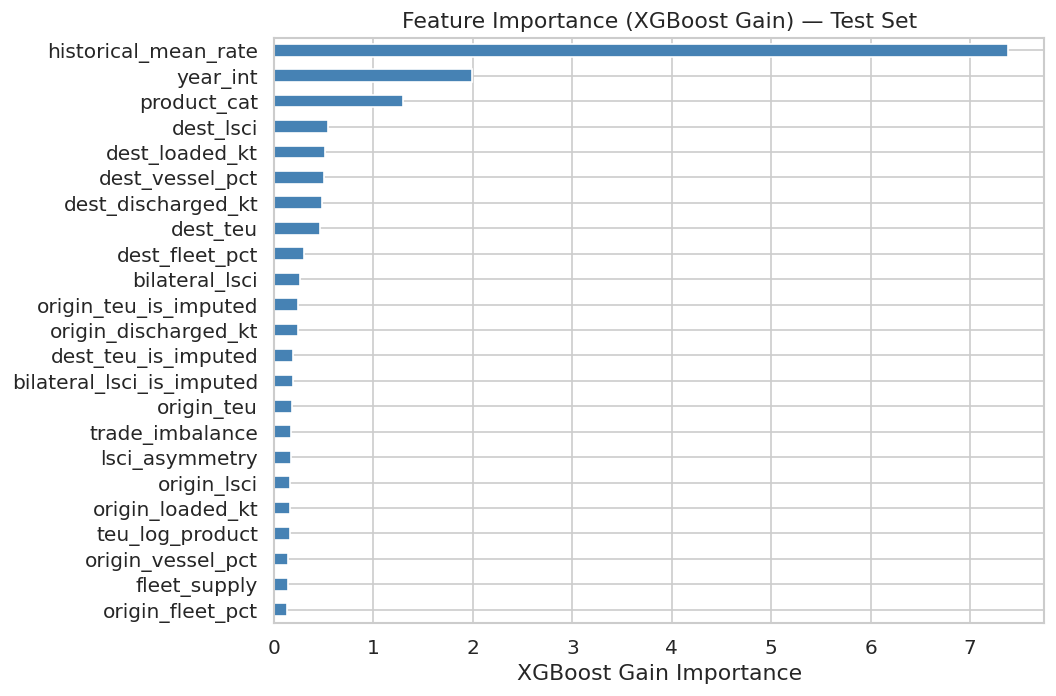

Top 5 most impactful features:
historical_mean_rate    7.380651
year_int                1.989220
product_cat             1.295856
dest_lsci               0.537950
dest_loaded_kt          0.512844


In [6]:
import pickle

# Load feature importance saved during training
with open(MODELS_DIR + 'shap_explainer.pkl', 'rb') as f:
    importance_data = pickle.load(f)

# importance_data is {'type': 'gain', 'importance': {feat: value, ...}}
importance_named = importance_data['importance']

mean_abs_shap = pd.Series(importance_named).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
mean_abs_shap.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('XGBoost Gain Importance')
ax.set_title('Feature Importance (XGBoost Gain) — Test Set')
plt.tight_layout()
plt.show()

print('Top 5 most impactful features:')
print(mean_abs_shap.sort_values(ascending=False).head(5).to_string())

## 6. SHAP Waterfall Example

Predicted freight rate for this corridor: 0.0989


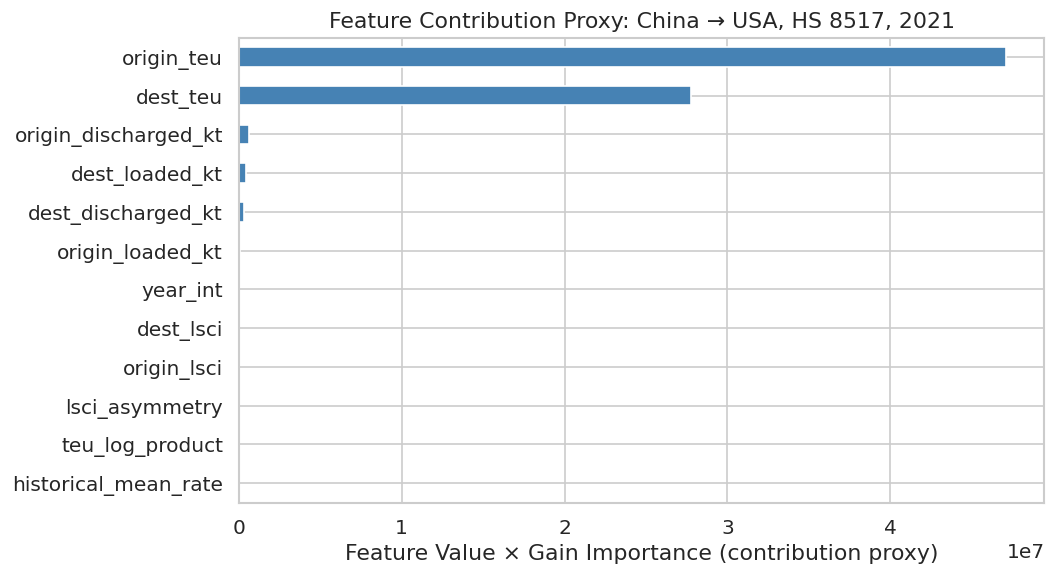

In [7]:
# Show feature contribution for China -> relevant origin, product 8517, year 2021
# (Using XGBoost predict with individual feature values as proxy for waterfall)
mask = (
    (df_full['origin'].str.lower().str.contains('china')) &
    (df_full['destination'].str.lower().str.contains('united states')) &
    (df_full['product_code'].astype(str) == '8517') &
    (df_full['year'].astype(int) == 2021)
)
example_rows = df_full[mask][avail].fillna(0)

if len(example_rows) == 0:
    print('Exact row not found — using closest proxy (first 2021 row with product 8517).')
    mask2 = (df_full['product_code'].astype(str) == '8517') & (df_full['year'].astype(int) == 2021)
    example_rows = df_full[mask2][avail].fillna(0).head(1)
    if len(example_rows) == 0:
        example_rows = df_full[df_full['year'].astype(int) == 2021][avail].fillna(0).head(1)

predicted_val = float(np.expm1(model.predict(example_rows.astype(float).iloc[[0]])[0]))
print(f'Predicted freight rate for this corridor: {predicted_val:.4f}')

# Plot feature values for this example row (normalized by feature importance)
feat_vals = example_rows.iloc[0]
feat_imp = pd.Series(importance_named)
# Align and compute scaled contribution proxy
common_feats = feat_vals.index.intersection(feat_imp.index)
contribution = (feat_vals[common_feats].abs() * feat_imp[common_feats]).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
contribution.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Value × Gain Importance (contribution proxy)')
ax.set_title('Feature Contribution Proxy: China → USA, HS 8517, 2021')
plt.tight_layout()
plt.show()

## 7. Imputation Results

Total graph edges: 375,522
Columns: ['origin', 'destination', 'product_code', 'product_label', 'freight_rate', 'year', 'bilateral_lsci', 'bilateral_lsci_is_imputed', 'origin_lsci', 'dest_lsci', 'origin_teu', 'origin_teu_is_imputed', 'dest_teu', 'dest_teu_is_imputed', 'origin_fleet_pct', 'dest_fleet_pct', 'origin_loaded_kt', 'origin_discharged_kt', 'dest_loaded_kt', 'dest_discharged_kt', 'origin_vessel_pct', 'dest_vessel_pct', 'historical_mean_rate', 'historical_mean_rate_is_imputed', 'lsci_asymmetry', 'trade_imbalance', 'teu_log_product', 'fleet_supply', 'post_covid', 'year_int', 'product_cat', 'is_predicted']

Observed edges:  239,499  (63.8%)
Predicted edges: 136,023  (36.2%)


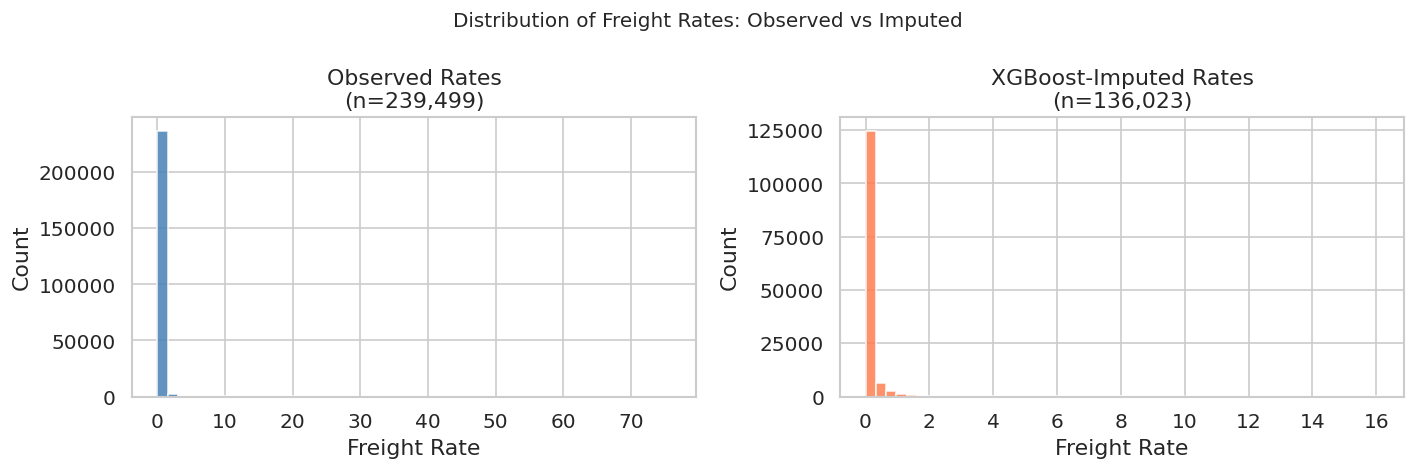


Observed  — median: 0.0780, mean: 0.1645
Imputed   — median: 0.0812, mean: 0.1502


In [8]:
edges = pd.read_parquet(PROCESSED_DIR + 'graph_edges_full.parquet')

print(f'Total graph edges: {len(edges):,}')
print(f'Columns: {edges.columns.tolist()}')

# The pipeline uses 'is_predicted' (True = ML-imputed, False = observed)
if 'is_observed' in edges.columns:
    is_obs_col = 'is_observed'
    n_observed  = edges['is_observed'].sum()
    n_predicted = (~edges['is_observed']).sum()
elif 'is_predicted' in edges.columns:
    is_obs_col = 'is_predicted'
    n_observed  = (~edges['is_predicted']).sum()
    n_predicted = edges['is_predicted'].sum()
else:
    is_obs_col = None
    n_observed  = len(edges)
    n_predicted = 0

pct_pred = n_predicted / len(edges) * 100 if len(edges) > 0 else 0
print(f'\nObserved edges:  {n_observed:,}  ({100 - pct_pred:.1f}%)')
print(f'Predicted edges: {n_predicted:,}  ({pct_pred:.1f}%)')

# Side-by-side distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

if is_obs_col == 'is_predicted':
    obs_rates  = edges[~edges['is_predicted']]['freight_rate'].dropna()
    pred_rates = edges[edges['is_predicted']]['freight_rate'].dropna()
elif is_obs_col == 'is_observed':
    obs_rates  = edges[edges['is_observed']]['freight_rate'].dropna()
    pred_rates = edges[~edges['is_observed']]['freight_rate'].dropna()
else:
    obs_rates  = edges['freight_rate'].dropna()
    pred_rates = pd.Series([], dtype=float)

axes[0].hist(obs_rates,  bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Observed Rates\n(n={len(obs_rates):,})')
axes[0].set_xlabel('Freight Rate')

axes[1].hist(pred_rates, bins=50, color='coral',     edgecolor='white', alpha=0.85)
axes[1].set_title(f'XGBoost-Imputed Rates\n(n={len(pred_rates):,})')
axes[1].set_xlabel('Freight Rate')

for ax in axes:
    ax.set_ylabel('Count')

fig.suptitle('Distribution of Freight Rates: Observed vs Imputed', fontsize=12)
plt.tight_layout()
plt.show()

if len(obs_rates) > 0:
    print(f'\nObserved  — median: {obs_rates.median():.4f}, mean: {obs_rates.mean():.4f}')
if len(pred_rates) > 0:
    print(f'Imputed   — median: {pred_rates.median():.4f}, mean: {pred_rates.mean():.4f}')